In [220]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import pickle 
import seaborn as sns
import random
import matplotlib.pyplot as plt
import os.path
import operator
from itertools import combinations
from random import randint
import json
import copy

In [2]:
def flatten_list(lst):
    flat_lst = [item for sublist in lst for item in sublist]
    return flat_lst

def reorder(lst,new_indices):
    new_lst = [lst[i] for i in new_indices]
    return new_lst 

def divide_planets(lst):
    p = 0
    block = []
    for g in range(len(lst)):
        curr_galaxy = lst[g]
        temp = []
        for planet in curr_galaxy:
            temp.append(p)
            p += 1
        block.append(temp)
    return block
        

def calc_pair_dist(pair):
    return abs(pair[0] - pair[1])-1 # number of planets in between these two, hence the minus 1 and absolute value 

def between(pair,block):
    """Checks if this pair of planets belong in different galaxies - or between event 
    pair(tuple) - pair of planets
    block(list) - a list of lists identifying which planets belong to which block"""
    flat_block = flatten_list(block) # need to flatten for the indexing we need to do 
    galaxy_1 = flat_block[pair[0]] # galaxy first planet belongs to 
    galaxy_2 = flat_block[pair[1]] # galaxy second planet belongs to
    
    return galaxy_1 != galaxy_2 # return True if they are not in the same galaxy 
    

In [3]:
def make_universe(sorted_dict,selection): # need to ensure dict is sorted by whatever metric you'd like 
    galaxy_order = [sorted_dict[y][1][0] for y in selection] # select top n -num blocks - sequences to be in the universe 
    all_blocks=[]
    for block in range(len(galaxy_order)):
        curr_block = list(galaxy_order[block].values())
        event_shifts = [i + 1 for (x, y, i) in zip(curr_block, curr_block[1:], range(len(curr_block))) if y != x] # store planets belonging to this neighborhood
        galaxies = [curr_block[start:end] for start, end in zip([0] + event_shifts, event_shifts + [len(curr_block)])]
        all_blocks.append(galaxies)
    return all_blocks

def get_rho0_and_decay(sorted_dict,selection,num_blocks):
    all_rho0 = []
    all_decay = []
    all_rpes = []
    for block in range(num_blocks):
        curr_rho0 = sorted_dict[selection[block]][1][1]
        curr_decay = sorted_dict[selection[block]][1][2]
        curr_rpes = sorted_dict[selection[block]][1][3]
        
        all_rho0.append(curr_rho0)
        all_decay.append(curr_decay)
        all_rpes.append(curr_rpes)
    return all_rho0,all_decay, all_rpes

In [4]:
def gen_new_cond(sorted_dict,selection, exp_struc):
    """ Generate other conditions by shuffling """
    n_blocks = len(exp_struc)
    new_struc =[]
    new_rho0 = []
    new_decay = []
    new_rpes = []
    for block in range(n_blocks):
        ind = list(range(len(exp_struc[block])))
        for i in range(3):
            random.shuffle(ind) # shuffle 3 times
        planets = divide_planets(exp_struc[block])
        planets = reorder(planets,ind) # reorder in the way the block was reordered
        planets_ind = flatten_list(planets) # flatten it 
        
        curr_struc = reorder(exp_struc[block],ind)
        curr_rho0 = reorder(sorted_dict[selection[block]][1][1],planets_ind)
        curr_decay = reorder(sorted_dict[selection[block]][1][2],planets_ind)
        curr_rpes = reorder(sorted_dict[selection[block]][1][3],planets_ind)
        
        new_struc.append(curr_struc)
        new_rho0.append(curr_rho0)
        new_decay.append(curr_decay)
        new_rpes.append(curr_rpes)
    return new_struc,new_rho0,new_decay,new_rpes
        

In [5]:
def pair_planets(num_planets,block):
    planets = range(num_planets)
    all_pairs = list(combinations(planets,2))
    list_of_pairs = []
    for i in range(len(all_pairs)):
        pair = all_pairs[i]
        list_of_pairs.append((pair,calc_pair_dist(pair),between(pair,block)))
    
    return list_of_pairs

def filter_recog_conditions(lst):
    within_zero = list(filter(lambda x: (x[1], x[2]) == (0,False) ,lst))
    within_one = list(filter(lambda x: (x[1], x[2]) == (1,False) ,lst))
    within_two = list(filter(lambda x: (x[1], x[2]) == (2,False) ,lst))

    between_zero = list(filter(lambda x: (x[1], x[2]) == (0,True) ,lst))
    between_one = list(filter(lambda x: (x[1], x[2]) == (1,True) ,lst))
    between_two = list(filter(lambda x: (x[1], x[2]) == (2,True) ,lst))
    
    combo = [within_zero,within_one,within_two,between_zero,between_one,between_two]
    return combo

def all_possible_recog_block(combo):
    my_sample = set()
    needed_size = len(combo[0])*len(combo[1])*len(combo[2])*len(combo[3])*len(combo[4])*len(combo[5])
    while len(my_sample) < needed_size:
        # Choose one random item from each list; that forms an element
        elem = tuple([comp[randint(0, len(comp)-1)][0] for comp in combo])
        # Using a set elminates duplicates easily
        my_sample.add(elem)
    my_sample=list(my_sample)
    return my_sample

def check_duplicates(lst):
    return len(lst) != len(set(lst))

def tuple_to_list(tup):
    """ Converts a tuple of tuples to a list of lists"""
    lst = [list(x) for x in tup]
    return lst

def sort_poss_recog(recog_blocks):
    all_poss_recog_trials = []
    for i in range(len(recog_blocks)):
        curr_set = recog_blocks[i]
        curr_set = flatten_list(curr_set)
        if not check_duplicates(curr_set): # check not duplicates in list, don't wanna ask about the same planet twice
            all_poss_recog_trials.append((recog_blocks[i],sum(curr_set)))
    if len(all_poss_recog_trials) == 0:
        for i in range(len(recog_blocks)):
            curr_set = recog_blocks[i]
            curr_set = flatten_list(curr_set)
        all_poss_recog_trials.append((recog_blocks[i],sum(curr_set)))
    
    all_poss_recog_trials = sorted(all_poss_recog_trials, key = lambda x: x[1]) # sort by sum, proxy by which lists emphasize earlier trials 
    return all_poss_recog_trials 

def make_recog_block(num_planets,block):
    all_pairs = pair_planets(num_planets,block) # all possible pairings of planets meeting the desired criteria
    categorized_pairs = filter_recog_conditions(all_pairs) # categorize them by distance and within/between galaxy 
    all_poss_recog_trials = all_possible_recog_block(categorized_pairs) # generate a set of recog trials meeting this criteria 

    all_poss_recog_trials = sort_poss_recog(all_poss_recog_trials)# sort by the blocks that prioritize early trials
    best_pick = all_poss_recog_trials[0][0] # pick first one 
    best_pick = tuple_to_list(best_pick)#turn a tuple of tuples into a list of lists (in prep to write to js file)
    return best_pick

def make_all_recog_blocks(n_blocks,n_planets,exp_struc):
    all_recog_blocks = []
    for block in range(n_blocks):   
        all_recog_blocks.append(make_recog_block(n_planets,exp_struc[block]))
    return all_recog_blocks 
    

In [168]:
max_bytes = 2**31 - 1
bytes_in = bytearray(0)
input_size = os.path.getsize('../pickled_exp_parms/max_between_rpes.pkl')
with open('../pickled_exp_parms/max_between_rpes.pkl', 'rb') as f_in:
    for _ in range(0, input_size, max_bytes):
        bytes_in += f_in.read(max_bytes)
data = pickle.loads(bytes_in)
poss_env_dict = pd.DataFrame(data)
f_in.close()

In [196]:
#arranged_kl = sorted(poss_env_dict.items(), key=lambda x : x[1][5])
# maximize the size of between galaxy rpes and the number of changepoints and minimize within rpes
arranged = sorted(poss_env_dict.items(), key=lambda x : (x[1][4],x[1][5],x[1][6],-x[1][7]),reverse=True)




In [198]:
arranged[1][1]

0    {1: 2, 2: 2, 3: 2, 4: 2, 5: 0, 6: 0, 7: 0, 8: ...
1    [99.67132936156071, 100.44936789779752, 96.388...
2    [[0.8789466823366378, 0.8920608405883281, 0.91...
3    [27.802986649489675, 13.36754755594275, 9.6362...
4                                                    3
5                                              3.55556
6                                              50.1534
7                                              4.92296
Name: 799, dtype: object

In [266]:
metric_max = 'between_rpe'
curr_metric = arranged
exp_struc = make_universe(curr_metric,[400,500,550])

In [267]:
exp_struc

[[[0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0], [2, 2, 2, 2]],
 [[1, 1, 1, 1], [2, 2, 2, 2, 2, 2, 2], [0, 0, 0, 0, 0], [1, 1, 1, 1]],
 [[1, 1, 1, 1, 1, 1, 1], [2, 2, 2, 2], [1, 1, 1, 1, 1], [0, 0, 0, 0]]]

In [271]:
n_blocks = 3
n_planets = 20
all_recog_blocks = make_all_recog_blocks(n_blocks,n_planets,exp_struc)

In [272]:
all_rho0, all_decay, all_rpes = get_rho0_and_decay(curr_metric,[400,500,550],n_blocks)

In [273]:
cond = 1
total_str = 'var r_0_'+str(cond)+' = %s;' % json.dumps(all_rho0) + 'var all_decay_'+str(cond)+' = %s;' % json.dumps(all_decay) +'var all_recog_'+str(cond)+' = %s;' % json.dumps(all_recog_blocks)

with open('../../run_exp/static/exp_struc/max_'+metric_max+'_cond_'+str(cond)+'.js', 'w') as out_file:
      out_file.write(total_str)
    
with open('../pickled_exp_parms/max_'+metric_max+'_cond_'+str(cond)+'.pkl','wb') as f:
    pickle.dump([exp_struc,all_rho0,all_decay,all_recog_blocks,all_rpes],f)


In [307]:
def save_new_cond(sorted_dict,selection,exp_struc,n_blocks,n_planets,metric_max):
    for cond in range(11,21):
        new_exp_struc, new_rho0, new_decay, new_rpes = gen_new_cond(sorted_dict,selection, exp_struc)
        all_recog_blocks = make_all_recog_blocks(n_blocks,n_planets,new_exp_struc)

        total_str = 'var r_0_'+str(cond)+' = %s;' % json.dumps(new_rho0) + 'var all_decay_'+str(cond)+' = %s;' % json.dumps(new_decay) +'var all_recog_'+str(cond)+' = %s;' % json.dumps(all_recog_blocks)

        with open('../../run_exp/static/exp_struc/max_'+metric_max+'_cond_'+str(cond)+'.js', 'w') as out_file:
              out_file.write(total_str)
    
        with open('../pickled_exp_parms/max_'+metric_max+'_cond_'+str(cond)+'.pkl','wb') as f:
            pickle.dump([new_exp_struc,new_rho0, new_decay,all_recog_blocks,new_rpes],f)
    return 


In [308]:
save_new_cond(curr_metric,[400,500,550],exp_struc,n_blocks,n_planets,metric_max)

In [213]:
def load_data(cond,metric_max):
    file = open('../pickled_exp_parms/max_'+metric_max+'_cond_'+str(cond)+'.pkl','rb')
    data= pickle.load(file)
    exp_struc = data[0]
    rho0 = data[1]
    all_decay = data[2]
    rpes = data[4]
    file.close()
    return exp_struc,rho0, all_decay,rpes

In [218]:
def get_prts_rpes(exp_struc,rho0,all_decay):
    rpes = []
    prts = []
    decay_rep ={0:[0.6],1:[0.6],2:[0.6]}
    for block in range(3):
        galaxies = flatten_list(exp_struc[block])
        temp_prts = []
        temp_rpes = []
        for planet in range(20):
            curr_r = rho0[block][planet]
            stay = 0
            while curr_r > 40:
                if (stay == 0) & (planet > 0):
                    galaxy_belief = galaxies[planet-1]
                else:
                    galaxy_belief = galaxies[planet]
                galaxy = galaxies[planet]
                pred_decay = sum(decay_rep[galaxy_belief])/len(decay_rep[galaxy_belief])
                actual_decay =min(max(all_decay[block][planet][stay],0),1)
                pred = curr_r*pred_decay
            

                curr_r = curr_r*actual_decay
                

                decay_rep[galaxy].append(actual_decay)

                temp_rpes.append(curr_r - pred)
                

                stay += 1
                
            temp_prts.append(stay)
        rpes.append(temp_rpes)
        prts.append(temp_prts)
    return rpes, prts

def get_event_shifts(exp_struc,rpes,prts):
    event_shifts = []
    for block in range(3):
        x=copy.copy(prts[block])
        x.insert(0,0)
        event_shifts.append(list(np.cumsum(x)))
    event_shifts[1] = [x+event_shifts[0][-1] for x in event_shifts[1]]
    event_shifts[2] = [x+event_shifts[1][-1] for x in event_shifts[2]]
    return event_shifts

In [334]:
cond=1
curr_exp_struc,rho0,all_decay,rpes=load_data(cond,metric_max)
all_rpes,prts = get_prts_rpes(curr_exp_struc,rho0,all_decay)
event_shifts = get_event_shifts(curr_exp_struc,all_rpes,prts)

In [335]:
curr_exp_struc

[[[0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0], [2, 2, 2, 2]],
 [[1, 1, 1, 1], [2, 2, 2, 2, 2, 2, 2], [0, 0, 0, 0, 0], [1, 1, 1, 1]],
 [[1, 1, 1, 1, 1, 1, 1], [2, 2, 2, 2], [1, 1, 1, 1, 1], [0, 0, 0, 0]]]

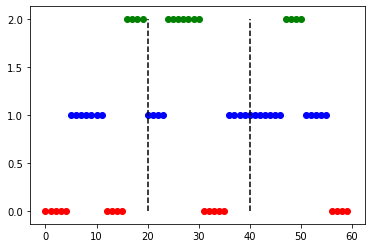

In [336]:
i = 0
for block in range(3):
    flat_struc = flatten_list(curr_exp_struc[block])
    if block == 1:
        plt.plot([i,i],[0,2],'k--')
    elif block == 2:
        plt.plot([i,i],[0,2],'k--')
    for planet in flat_struc:
        if planet == 0:
            plt.scatter(i,planet,color='red')
        elif planet == 1:
            plt.scatter(i,planet,color='blue')
        elif planet == 2:
            plt.scatter(i,planet,color='green')
            
        i += 1
plt.savefig('max_'+metric_max+'_no_rpe_task_structure_cond_'+str(cond)+'.png')

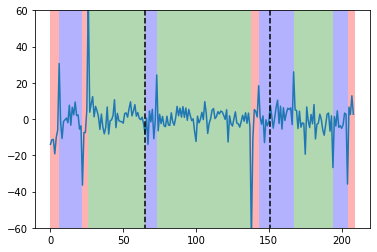

In [337]:
import copy
flat_rpes = flatten_list(all_rpes)
plt.plot(flat_rpes)
plt.plot([event_shifts[0][-1],event_shifts[0][-1]],[60,-60],'k--')
plt.plot([event_shifts[1][-1],event_shifts[1][-1]],[60,-60],'k--')
for block in range(3):
    curr_ev = event_shifts[block]
    flat_struc = flatten_list(curr_exp_struc[block])
    for i in range(20): # loop thru neighborhoods 
        item = flat_struc[i]
    
        start_event = curr_ev[i]
        end_event = curr_ev[i+1]
        
        if item == 0:
            plt.axvspan(start_event, end_event, facecolor='r', alpha=0.3)
        elif item == 1:
            plt.axvspan(start_event, end_event, facecolor='b', alpha=0.3)
        elif item == 2:
            plt.axvspan(start_event, end_event, facecolor='g', alpha=0.3)
plt.ylim([-60,60])
plt.savefig('max_'+metric_max+'_task_structure_cond_'+str(cond)+'.png')

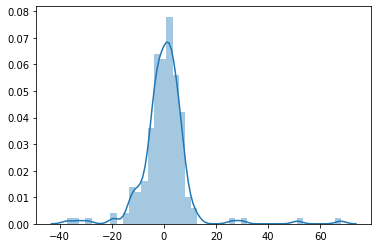

In [333]:
sns.distplot(flat_rpes)
plt.savefig('max_'+metric_max+'_dist_rpes_cond_'+str(cond)+'.png')